In [184]:
import pandas as pd
import pandas_gbq as pd_gbq
import numpy as np
import os
import matplotlib.pyplot as plt
from google.cloud import bigquery
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from haversine import haversine
from sklearn.metrics import silhouette_score
import joblib

os.chdir('D:\Projects\price-optimization-demand-elasticity')

# main_folder_path = os.path.dirname(os.getcwd())
# os.chdir(main_folder_path)

In [107]:
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = 'GCP_key.json'
project_id = 'price-optimization-hris4498'
client = bigquery.Client(project=project_id)


# Geo-segmentation:

 ### Segment your stores based on geographic location and run separate price optimization models for each segment.

In [125]:
query=f"""
SELECT distinct
  store_number,
  AVG(st_x(store_location)) AS longitude,
  AVG(st_y(store_location)) AS latitude,
  ROUND(SUM(sale_dollars),2) AS tot_sale_dollars
FROM
    `{project_id}.iowa_liqour_sales.sales`
WHERE 
    store_location is not null
GROUP BY
  store_number"""
store_loc_sales_df = pd.read_gbq(query=query,project_id=project_id)
# print(query)

In [126]:
# Create a GeoDataFrame
store_loc_sales_gdf = gpd.GeoDataFrame(store_loc_sales_df, 
                              geometry=gpd.points_from_xy(store_loc_sales_df.longitude, store_loc_sales_df.latitude))


In [127]:
os.getcwd()+"\\maps\\store_locations.html"

'D:\\Projects\\price-optimization-demand-elasticity\\maps\\store_locations.html'

In [128]:
# Plot on a map using Folium
store_map = folium.Map(location=[38.3892948,-92.4113947], zoom_start=4)
for idx, row in store_loc_sales_gdf.iterrows():
    folium.Marker([row.geometry.y, row.geometry.x], popup=row['store_number']).add_to(store_map)
store_map.save(os.getcwd()+"\\maps\\store_locations.html")

In [129]:
# Create a heatmap of sales
store_heatmap = folium.Map(location=[38.3892948,-92.4113947], zoom_start=4)
heat_data = [[row.geometry.y, row.geometry.x, row['tot_sale_dollars']] for index, row in store_loc_sales_gdf.iterrows()]
HeatMap(heat_data).add_to(store_heatmap)
store_heatmap.save(os.getcwd()+"\\maps\\store_sales_heatmap.html")

<Axes: >

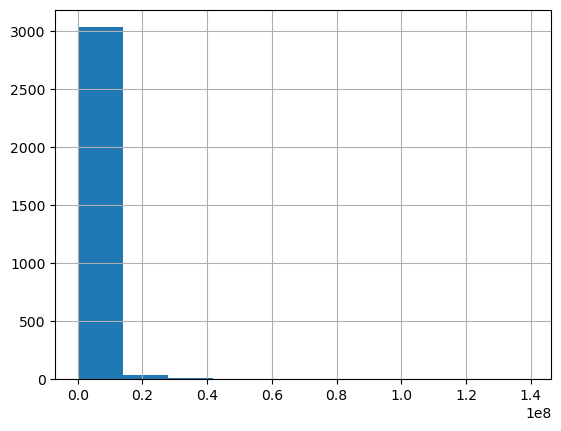

In [130]:
store_loc_sales_df['tot_sale_dollars'].hist()

In [131]:
# Log transformation of sales data as it is skewed
store_loc_sales_df['log_sales'] = np.log(store_loc_sales_df['tot_sale_dollars'] + 1)

In [132]:
# Geosegementation based on location by K Means method
# kmeans = KMeans(n_clusters=4)
# # Fit the model
# store_loc_sales_df['cluster'] = kmeans.fit_predict(store_loc_sales_df[['longitude', 'latitude', 'log_sales']])

# # Plot each cluster separately
# for cluster in range(4):
#     cluster_data = store_loc_sales_df[store_loc_sales_df['cluster'] == cluster]
#     plt.figure(figsize=(8, 6))
#     plt.scatter(cluster_data['longitude'], cluster_data['latitude'], c='blue', label='Cluster ' + str(cluster))
#     plt.title(f'Cluster {cluster}')
#     plt.xlabel('Longitude')
#     plt.ylabel('Latitude')
#     plt.legend()
#     plt.grid()
#     plt.savefig(f'cluster_{cluster}.png')  # Save each plot
#     plt.show()

In [133]:
# Geosegementation based on location by DBscan as it is less sensitive to outliers
# Scale the features
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(store_loc_sales_df[['longitude', 'latitude', 'tot_sale_dollars']])

# # DBSCAN model
# dbscan = DBSCAN(eps=0.5, min_samples=2)  # Adjust parameters as needed
# store_loc_sales_df['cluster'] = dbscan.fit_predict(scaled_features)

# # Plot each cluster separately
# for cluster in range(4):
#     cluster_data = store_loc_sales_df[store_loc_sales_df['cluster'] == cluster]
#     plt.figure(figsize=(8, 6))
#     plt.scatter(cluster_data['longitude'], cluster_data['latitude'], c='blue', label='Cluster ' + str(cluster))
#     plt.title(f'Cluster {cluster}')
#     plt.xlabel('Longitude')
#     plt.ylabel('Latitude')
#     plt.legend()
#     plt.grid()
#     plt.savefig(f'cluster_{cluster}.png')  # Save each plot
#     plt.show()


### By location and sale for both DB scan and KMeans is having poor results, Calculate nearest city distance as mew feature and try again

In [134]:
def distance_to_city(store_location, city_location):
    return haversine(store_location, city_location)

# Major cities in Iowa
cities = {
    'Des Moines': (41.5868, -93.6250),
    'Cedar Rapids': (41.9779, -91.6640),
    'Davenport': (41.5236, -90.5770),
    'Sioux City': (42.4999, -96.4003),
    'Iowa City': (41.6611, -91.5302),
    'Waterloo': (42.4926, -92.3426),
}


In [135]:
# Find the nearest city for each store
def find_nearest_city(store):
    store_location = (store['latitude'], store['longitude'])
    nearest_city = None
    min_distance = float('inf')
    
    for city_name, city_location in cities.items():
        distance = distance_to_city(store_location, city_location)
        if distance < min_distance:
            min_distance = distance
            nearest_city = city_name
            
    return nearest_city, min_distance

# Apply the function to each store
store_loc_sales_df['nearest_city'], store_loc_sales_df['distance_to_city_km'] = zip(*store_loc_sales_df.apply(find_nearest_city, axis=1))


c:\Users\91940\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\91940\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\91940\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\91940\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\91940\anaconda3\lib\site-packages\sklearn\clust

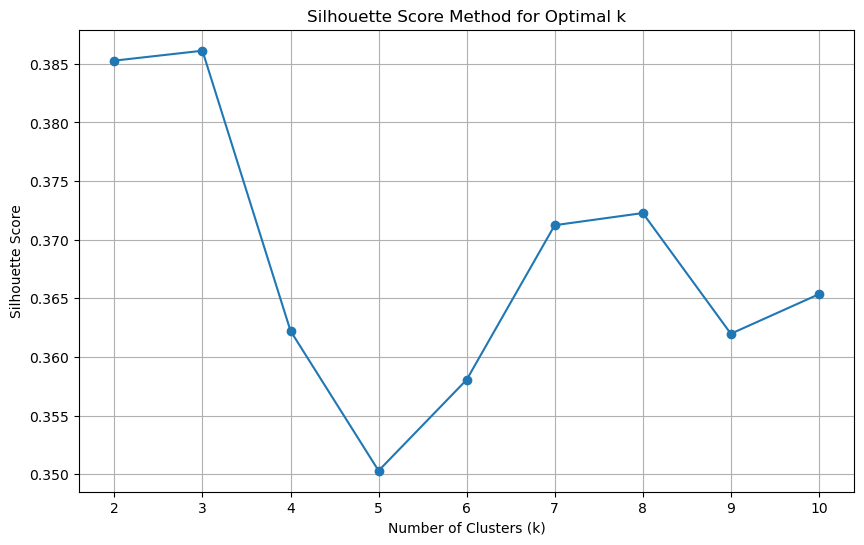

In [178]:
#Geosegementation based on location by K Means method with elbow method for best cluster number
X = store_loc_sales_df[['log_sales', 'distance_to_city_km']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
k_range = range(1, 11) 
silhouette_scores = []

for k in k_range[1:]:  # Start from 2 for silhouette score
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range[1:], silhouette_scores, marker='o')
plt.title('Silhouette Score Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range[1:])
plt.grid()
plt.show()


c:\Users\91940\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


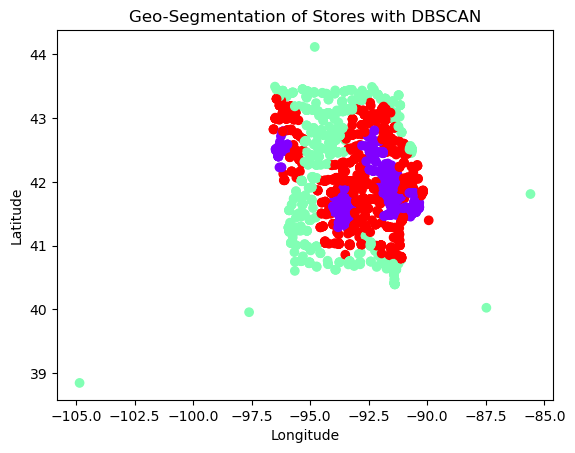

In [187]:
n_clusters = 3 # according to silhouette scaoe best cluster
kmeans = KMeans(n_clusters=n_clusters,random_state=42)
# Fit the model
store_loc_sales_df['cluster'] = kmeans.fit_predict(store_loc_sales_df[['log_sales','distance_to_city_km']])

# Save the model
joblib.dump(kmeans, os.getcwd()+"\\models\\store_geo_segment_model.pkl")

# Visualize the clusters
plt.scatter(store_loc_sales_df['longitude'], store_loc_sales_df['latitude'], c=store_loc_sales_df['cluster'], cmap='rainbow')
plt.title('Geo-Segmentation of Stores with DBSCAN')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Demand Forecasting for every cluster and brand combination